# Stage 9: Cross-method Comparison Figures

This notebook reads Stage 9 outputs from `results/comparison/` and renders the required comparison figures.

Figures are saved to `results/comparison/figures/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "comparison").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
COMPARISON_DIR = ROOT / "results" / "comparison"
FIGURES_DIR = COMPARISON_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

summary_paths = {
    "classifier": COMPARISON_DIR / "classifier_summary.parquet",
    "cross_method_pvalues": COMPARISON_DIR / "cross_method_pvalues.parquet",
    "stability": COMPARISON_DIR / "stability_summary.parquet",
    "selection_curve": COMPARISON_DIR / "selection_frequency_curve.parquet",
    "enrichment": COMPARISON_DIR / "enrichment_summary.parquet",
    "recall": COMPARISON_DIR / "recall_summary.parquet",
    "fdp": COMPARISON_DIR / "fdp_summary.parquet",
    "full_data": COMPARISON_DIR / "full_data_summary.parquet",
    "full_data_overlap": COMPARISON_DIR / "full_data_overlap.parquet",
}

missing = [name for name, path in summary_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing Stage 9 summaries in {COMPARISON_DIR}: {missing}. Run scripts/06_aggregate_results.py first."
    )

classifier_summary = pd.read_parquet(summary_paths["classifier"])
cross_method_pvalues = pd.read_parquet(summary_paths["cross_method_pvalues"])
stability_summary = pd.read_parquet(summary_paths["stability"])
selection_curve = pd.read_parquet(summary_paths["selection_curve"])
enrichment_summary = pd.read_parquet(summary_paths["enrichment"])
recall_summary = pd.read_parquet(summary_paths["recall"])
fdp_summary = pd.read_parquet(summary_paths["fdp"])
full_data_summary = pd.read_parquet(summary_paths["full_data"])
full_data_overlap = pd.read_parquet(summary_paths["full_data_overlap"])


def p_to_stars(p: float) -> str:
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


print(f"Detected project root: {ROOT}")
print(f"Comparison directory: {COMPARISON_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Detected project root: c:\Programmering\exjobb\MSc26_Proteomics
Comparison directory: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison
Figures directory: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures


In [2]:
coverage = pd.DataFrame(
    {
        "table": [
            "classifier_summary",
            "stability_summary",
            "selection_frequency_curve",
            "enrichment_summary",
            "recall_summary",
            "fdp_summary",
            "full_data_summary",
            "full_data_overlap",
        ],
        "rows": [
            len(classifier_summary),
            len(stability_summary),
            len(selection_curve),
            len(enrichment_summary),
            len(recall_summary),
            len(fdp_summary),
            len(full_data_summary),
            len(full_data_overlap),
        ],
    }
)

display(coverage)
display(stability_summary)
display(full_data_summary)
display(full_data_overlap)

,table,rows
0,classifier_summary,30
1,stability_summary,2
2,selection_frequency_curve,21552
3,enrichment_summary,6
4,recall_summary,150
5,fdp_summary,10
6,full_data_summary,2
7,full_data_overlap,3


,method,stable_size_pi_0_3,top_frequency,n_ge_0_5,n_ge_0_3,mean_jaccard_top50
0,random,0,0.06,0,0,0.002422
1,ttest,4,0.96,2,4,0.209776


,method,n_significant,top_protein,top_score
0,random,20,seq.9402.18,0.312309
1,ttest,12,seq.26103.20,-0.065493


,method_a,method_b,n_a,n_b,n_intersection,n_union,jaccard
0,random,random,20,20,20,20,1.0
1,random,ttest,20,12,0,32,0.0
2,ttest,ttest,12,12,12,12,1.0


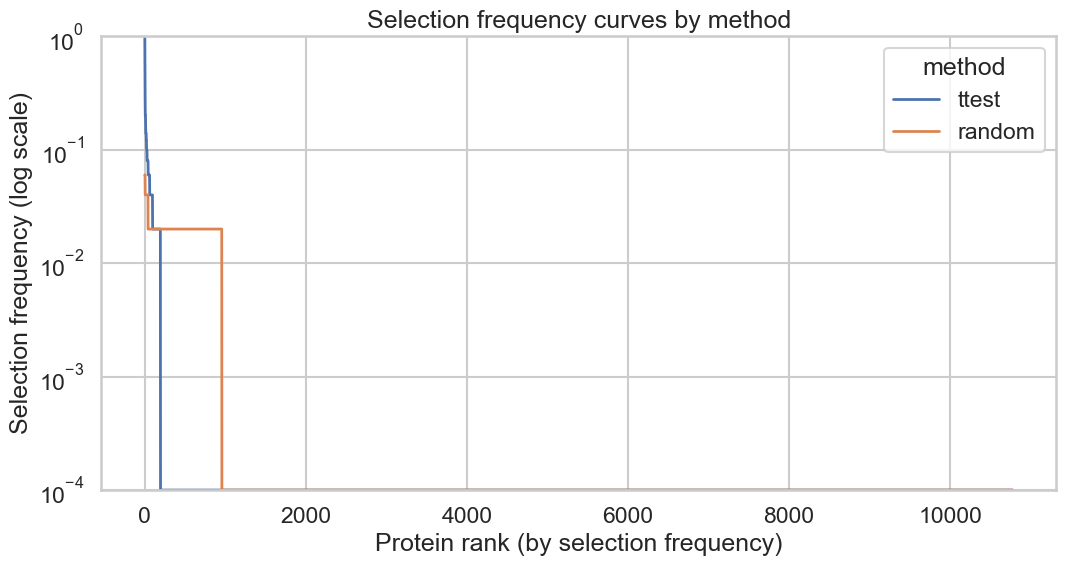

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\selection_frequency_curves.png


In [3]:
curve_plot = selection_curve.copy()
curve_plot["frequency_plot"] = curve_plot["frequency"].clip(lower=1e-4)

plt.figure(figsize=(11, 6))
ax = sns.lineplot(
    data=curve_plot,
    x="rank",
    y="frequency_plot",
    hue="method",
    linewidth=2.0,
)
ax.set_yscale("log")
ax.set_xlabel("Protein rank (by selection frequency)")
ax.set_ylabel("Selection frequency (log scale)")
ax.set_title("Selection frequency curves by method")
ax.set_ylim(1e-4, 1.0)
ax.legend(title="method")

fig1_path = FIGURES_DIR / "selection_frequency_curves.png"
plt.tight_layout()
plt.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig1_path}")

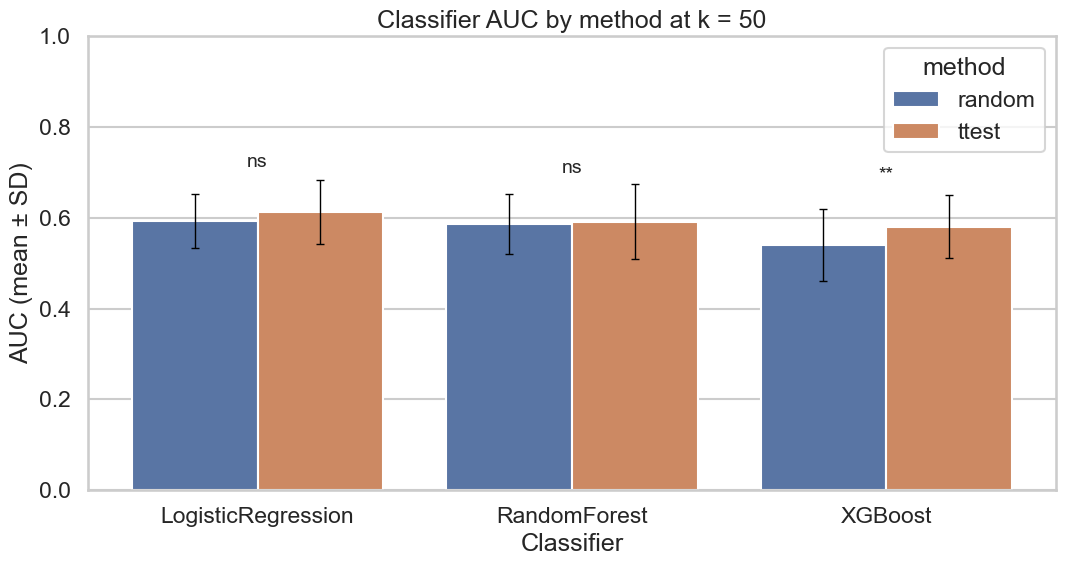

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\classifier_auc_k50.png


In [4]:
auc_k50 = classifier_summary[classifier_summary["k"].astype(str) == "50"].copy()
if auc_k50.empty:
    raise ValueError("No rows with k='50' in classifier_summary.parquet")

auc_k50 = auc_k50.sort_values(["classifier", "method"], kind="mergesort").reset_index(drop=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=auc_k50,
    x="classifier",
    y="auc_mean",
    hue="method",
    errorbar=None,
)

for patch, (_, row) in zip(ax.patches, auc_k50.iterrows()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    yerr = row["auc_sd"] if pd.notna(row["auc_sd"]) else 0.0
    ax.errorbar(x, y, yerr=yerr, color="black", capsize=3, linewidth=1)

methods_present = sorted(auc_k50["method"].astype(str).unique().tolist())
classifiers_order = [t.get_text() for t in ax.get_xticklabels()]
if len(methods_present) == 2:
    pv_k50 = cross_method_pvalues[
        (cross_method_pvalues["metric"] == "auc")
        & (cross_method_pvalues["k"].astype(str) == "50")
    ]
    for xi, clf in enumerate(classifiers_order):
        row = pv_k50[pv_k50["classifier"] == clf]
        if row.empty:
            continue
        stars = p_to_stars(float(row.iloc[0]["p_value"]))
        if not stars:
            continue
        bars = auc_k50[auc_k50["classifier"] == clf]
        top = float(
            (bars["auc_mean"].fillna(0.0) + bars["auc_sd"].fillna(0.0)).max()
        )
        ax.annotate(
            stars,
            xy=(xi, top),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=14,
        )

ax.set_xlabel("Classifier")
ax.set_ylabel("AUC (mean ± SD)")
ax.set_title("Classifier AUC by method at k = 50")
ax.set_ylim(0.0, 1.0)
ax.legend(title="method")

fig2_path = FIGURES_DIR / "classifier_auc_k50.png"
plt.tight_layout()
plt.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig2_path}")

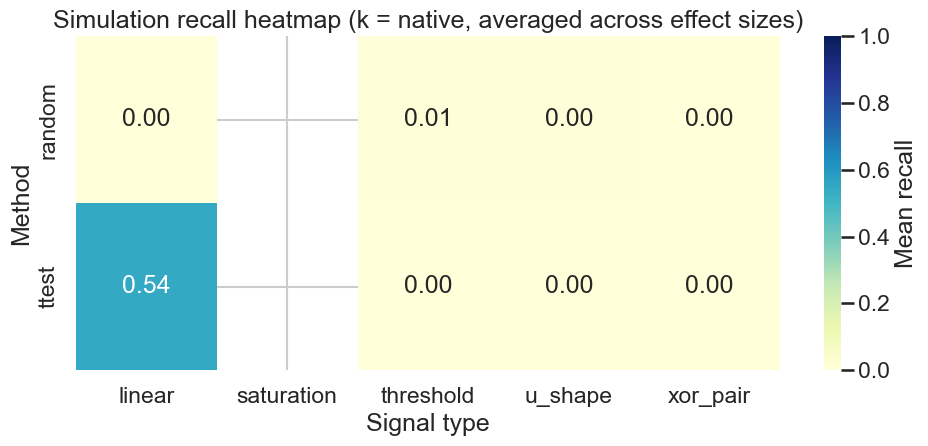

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\simulation_recall_heatmap.png


In [5]:
sim_native = recall_summary[recall_summary["k"].astype(str) == "native"].copy()
if sim_native.empty:
    raise ValueError("No rows with k='native' in recall_summary.parquet")

recall_heat = (
    sim_native.groupby(["method", "signal_type"], observed=False)
    .agg(recall_mean=("recall_mean", "mean"))
    .reset_index()
)

signal_order = ["linear", "saturation", "threshold", "u_shape", "xor_pair"]
method_order = sorted(recall_heat["method"].astype(str).unique().tolist())

heatmap_matrix = (
    recall_heat.pivot(index="method", columns="signal_type", values="recall_mean")
    .reindex(index=method_order, columns=signal_order)
)

plt.figure(figsize=(10, 4.8))
ax = sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": "Mean recall"},
)
ax.set_xlabel("Signal type")
ax.set_ylabel("Method")
ax.set_title("Simulation recall heatmap (k = native, averaged across effect sizes)")

fig3_path = FIGURES_DIR / "simulation_recall_heatmap.png"
plt.tight_layout()
plt.savefig(fig3_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig3_path}")

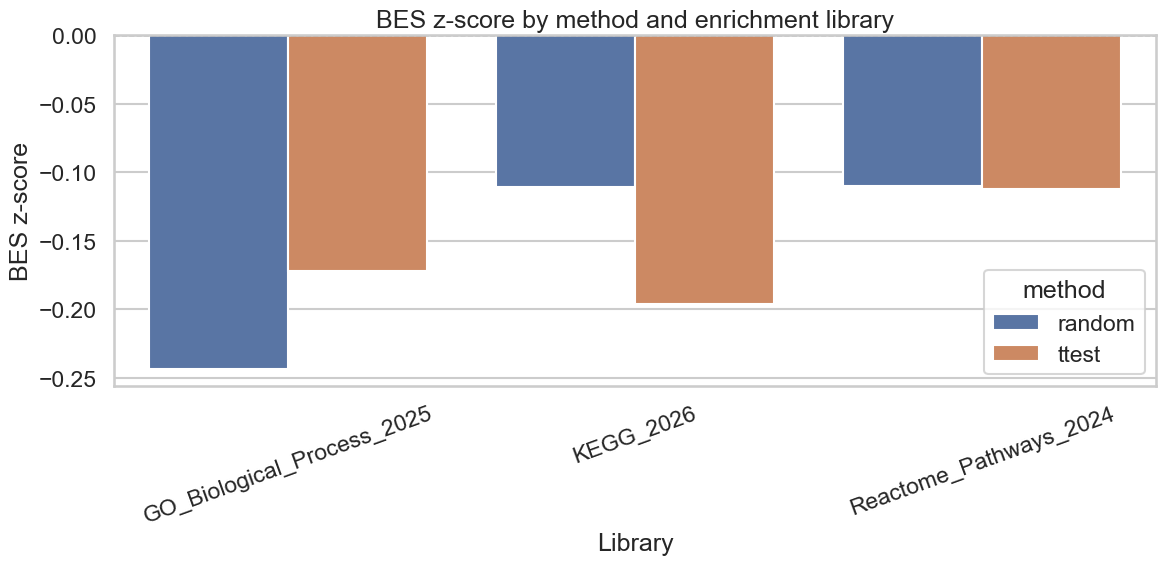

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\bes_z_scores.png


In [6]:
enrichment_plot = enrichment_summary.copy()
enrichment_plot["bes_z"] = pd.to_numeric(enrichment_plot["bes_z"], errors="coerce")

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=enrichment_plot,
    x="library",
    y="bes_z",
    hue="method",
    errorbar=None,
)
ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Library")
ax.set_ylabel("BES z-score")
ax.set_title("BES z-score by method and enrichment library")
ax.legend(title="method")
ax.tick_params(axis="x", rotation=20)

fig4_path = FIGURES_DIR / "bes_z_scores.png"
plt.tight_layout()
plt.savefig(fig4_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {fig4_path}")

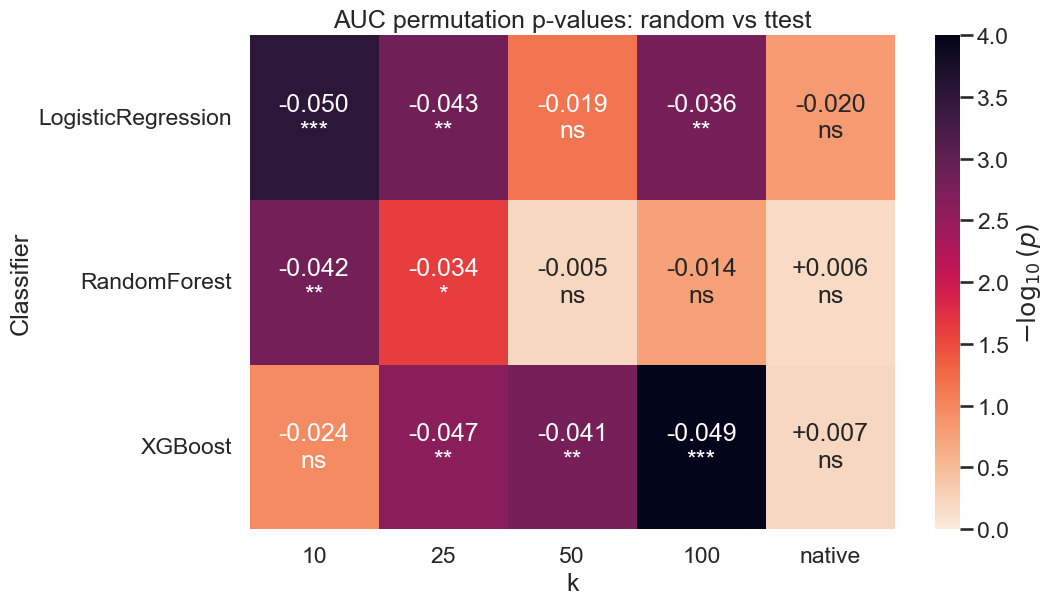

Saved: c:\Programmering\exjobb\MSc26_Proteomics\results\comparison\figures\classifier_pvalues_heatmap.png


In [7]:
auc_pvalues = cross_method_pvalues[cross_method_pvalues["metric"] == "auc"].copy()
auc_pvalues["pair"] = auc_pvalues["method_a"].astype(str) + " vs " + auc_pvalues["method_b"].astype(str)
pair_order = sorted(auc_pvalues["pair"].unique().tolist())
k_order_fig = ["10", "25", "50", "100", "native"]
classifiers_order_pv = sorted(auc_pvalues["classifier"].unique().tolist())

fig5, axes5 = plt.subplots(
    len(pair_order),
    1,
    figsize=(11, 1.0 + 1.8 * len(classifiers_order_pv) * len(pair_order)),
    squeeze=False,
)

for i, pair in enumerate(pair_order):
    ax = axes5[i][0]
    sub = auc_pvalues[auc_pvalues["pair"] == pair]
    color_mat = (
        sub.pivot(index="classifier", columns="k", values="p_value")
        .reindex(index=classifiers_order_pv, columns=k_order_fig)
        .apply(lambda col: -np.log10(col.clip(lower=1e-10)))
    )
    diff_mat = sub.pivot(index="classifier", columns="k", values="mean_diff").reindex(
        index=classifiers_order_pv, columns=k_order_fig
    )
    p_mat = sub.pivot(index="classifier", columns="k", values="p_value").reindex(
        index=classifiers_order_pv, columns=k_order_fig
    )
    annot_text = diff_mat.copy().astype(object)
    for r in diff_mat.index:
        for c in diff_mat.columns:
            v = diff_mat.loc[r, c]
            s = p_to_stars(p_mat.loc[r, c])
            annot_text.loc[r, c] = "" if pd.isna(v) else (f"{v:+.3f}\n{s}" if s else f"{v:+.3f}")

    sns.heatmap(
        color_mat,
        annot=annot_text.values,
        fmt="",
        cmap="rocket_r",
        vmin=0.0,
        vmax=4.0,
        cbar_kws={"label": r"$-\log_{10}(p)$"},
        ax=ax,
    )
    ax.set_title(f"AUC permutation p-values: {pair}")
    ax.set_xlabel("k")
    ax.set_ylabel("Classifier")

fig5.tight_layout()
fig5_path = FIGURES_DIR / "classifier_pvalues_heatmap.png"
fig5.savefig(fig5_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fig5_path}")

In [8]:
saved_figures = [
    FIGURES_DIR / "selection_frequency_curves.png",
    FIGURES_DIR / "classifier_auc_k50.png",
    FIGURES_DIR / "simulation_recall_heatmap.png",
    FIGURES_DIR / "bes_z_scores.png",
    FIGURES_DIR / "classifier_pvalues_heatmap.png",
]

status = pd.DataFrame(
    {
        "figure": [p.name for p in saved_figures],
        "exists": [p.exists() for p in saved_figures],
        "path": [str(p) for p in saved_figures],
    }
)

display(status)

,figure,exists,path
0,selection_frequency_curves.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
1,classifier_auc_k50.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
2,simulation_recall_heatmap.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
3,bes_z_scores.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
4,classifier_pvalues_heatmap.png,True,c:\Programmering\exjobb\MSc26_Proteomics\resul...
